# Prédiction du tarif journalier de la location

🎯 Objectifs :

Entrainer un modèle de machine learning supervisé qui va pouvoir prédire la tarfication à la journée pour un véhicule en fonction des autres critères de la base de données.

plan :

1 - Importer les données et analyser les données de tarification

2 - Etape de Pré-Processing :

3 - Entrainnement des modèles :
   - Régression linéaire
   - Random Forest Regressor

4 - Comparaison des métriques

5 - Sauvegarde du modèle


# 1 - Importer les données et analyser les données de tarification

In [68]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score ,root_mean_squared_error

import mlflow
import joblib



In [69]:

# bloc paramétrage Mlflow
URL_HF_SPACE = "https://gull1979-mlflow-tracking-ft.hf.space/" 
mlflow.set_tracking_uri(URL_HF_SPACE)

# url temporaire pour éviter de dépasser le quota sql de Neon
#mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment("GetAround_project")

2026/07/01 13:45:20 INFO mlflow.tracking.fluent: Experiment with name 'GetAround_project' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://fullstack-exo/mlflow-tracking/3', creation_time=1782906320338, experiment_id='3', last_update_time=1782906320338, lifecycle_stage='active', name='GetAround_project', tags={}, trace_location=None, workspace='default'>

In [70]:
df = pd.read_csv("src/get_around_pricing_project.csv")

In [71]:
df.shape

(4843, 15)

In [72]:
df.describe(include='all')

,Unnamed: 0,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
count,4843.000000,4843,4.843000e+03,4843.00000,4843,4843,4843,4843,4843,4843,4843,4843,4843,4843,4843.000000
unique,NaN,28,NaN,NaN,4,10,8,2,2,2,2,2,2,2,NaN
top,NaN,Citroën,NaN,NaN,diesel,black,estate,True,True,False,False,False,False,True,NaN
freq,NaN,969,NaN,NaN,4641,1633,1606,2662,3839,3865,3881,2613,3674,4514,NaN
mean,2421.000000,NaN,1.409628e+05,128.98823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.214536
std,1398.198007,NaN,6.019674e+04,38.99336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.568268
min,0.000000,NaN,-6.400000e+01,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000
25%,1210.500000,NaN,1.029135e+05,100.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.000000
50%,2421.000000,NaN,1.410800e+05,120.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119.000000
75%,3631.500000,NaN,1.751955e+05,135.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.000000


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Unnamed: 0                 4843 non-null   int64 
 1   model_key                  4843 non-null   object
 2   mileage                    4843 non-null   int64 
 3   engine_power               4843 non-null   int64 
 4   fuel                       4843 non-null   object
 5   paint_color                4843 non-null   object
 6   car_type                   4843 non-null   object
 7   private_parking_available  4843 non-null   bool  
 8   has_gps                    4843 non-null   bool  
 9   has_air_conditioning       4843 non-null   bool  
 10  automatic_car              4843 non-null   bool  
 11  has_getaround_connect      4843 non-null   bool  
 12  has_speed_regulator        4843 non-null   bool  
 13  winter_tires               4843 non-null   bool  
 14  rental_p

### Il n'y a pas de valeurs manquantes

# Feature engineering

In [74]:
colonnes_a_sup = ['Unnamed: 0', 'mileage']
df_clean = df.drop(columns=colonnes_a_sup)

### Supression des outliers par la méthode de l'IQR (Tukey), quantile

In [75]:
Q1 = df_clean['rental_price_per_day'].quantile(0.25)
Q3 = df_clean['rental_price_per_day'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_clean = df_clean[(df_clean['rental_price_per_day'] >= lower) & (df_clean['rental_price_per_day'] <= upper)]
df_clean.shape


(4498, 13)

In [76]:
# suppression de la classe model_key = 'Mazda', elle n'a qu'une seul observation
df_clean = df_clean[df_clean['model_key'] != 'Mazda']

In [77]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4497 entries, 0 to 4842
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   model_key                  4497 non-null   object
 1   engine_power               4497 non-null   int64 
 2   fuel                       4497 non-null   object
 3   paint_color                4497 non-null   object
 4   car_type                   4497 non-null   object
 5   private_parking_available  4497 non-null   bool  
 6   has_gps                    4497 non-null   bool  
 7   has_air_conditioning       4497 non-null   bool  
 8   automatic_car              4497 non-null   bool  
 9   has_getaround_connect      4497 non-null   bool  
 10  has_speed_regulator        4497 non-null   bool  
 11  winter_tires               4497 non-null   bool  
 12  rental_price_per_day       4497 non-null   int64 
dtypes: bool(7), int64(2), object(4)
memory usage: 276.7+ KB


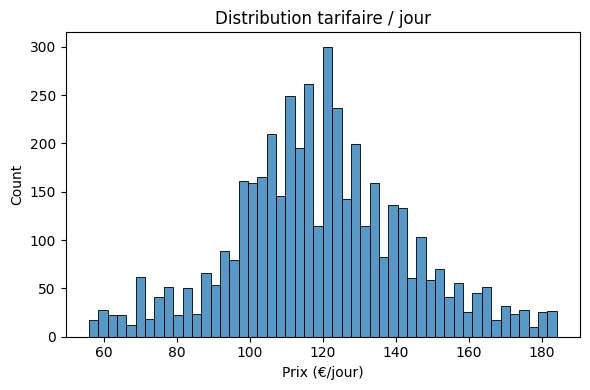

In [78]:
# distribution de la cible

plt.figure(figsize=(6,4))
sns.histplot(df_clean['rental_price_per_day'], bins=50)
plt.title("Distribution tarifaire / jour")
plt.xlabel("Prix (€/jour)")
plt.tight_layout()
plt.show()

# 2 - Etape de Pré-Processing :

In [79]:
target = ['rental_price_per_day']

# liste des variables explicatives : toutes les colonnes sauf rental_price_per_day
X = df_clean.loc[:, ~df_clean.columns.isin(target)] 

# Variable cible rental_price_per_day
y = df_clean.loc[:, df_clean.columns.isin(target)]


In [80]:
# séparation des données en fonction de leur type (numérique / catégorielle)
# Tout ce qui n'est pas du type object est une colonne numérique
# inversement pour catégorielle

numeric_feature = list(X.select_dtypes(exclude=["object"]).columns)
print("Liste des colonnes numériques:", numeric_feature)

cat_feature = list(X.select_dtypes(include=["object"]).columns)
print("Liste des colonnes catégorielles:", cat_feature)


Liste des colonnes numériques: ['engine_power', 'private_parking_available', 'has_gps', 'has_air_conditioning', 'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
Liste des colonnes catégorielles: ['model_key', 'fuel', 'paint_color', 'car_type']


### Pipeline



In [81]:
# Il n' y a pas de valeurs manquantes mais il faut tout de même faire cette étape si d'autres données devaient servir à entrainner les modèles
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Focus sur l'encoder catégorielle (one hot encoder)
    # ce dataset contient beaucoup de colonnes catégorielles et de classes
        #utiliser un autre encoder comme le targetencoder pourrait aider le modèle à mieux conversger
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OHE", OneHotEncoder(drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_feature),
        ("cat", categorical_transformer, cat_feature),
    ]
)

In [82]:
# séparation avec 80% de train et 20% de test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


# 3 - Entrainnement des modèles :

## Régression linéaire

In [83]:
pipe_linear_regressor = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [84]:
pipe_linear_regressor.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [85]:
# métriques choisies : 
    # R2 (Test/Train)  
    # MAE (moyenne des écarts entre prédi et la cible) 
    # RMSE (Racine carré du carré de la moyenne des écarts)
y_pred_train = pipe_linear_regressor.predict(X_train)
y_pred_test = pipe_linear_regressor.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_test)
rmse_linear = root_mean_squared_error(y_test, y_pred_test) 
r2_linear_train = r2_score(y_train, y_pred_train)
r2_linear_test = r2_score(y_test, y_pred_test)
ecart_overfitting = r2_linear_train-r2_linear_test


with mlflow.start_run(run_name="LinearRegression"):

    # metric MLFLOW
    mlflow.log_metric("R2_test", r2_linear_test)
    mlflow.log_metric("R2_train", r2_linear_train)    
    mlflow.log_metric("Ecart_Overfitting", ecart_overfitting)
    mlflow.log_metric("MAE_test", mae_linear)
    mlflow.log_metric("RMSE_test", rmse_linear)
    

🏃 View run LinearRegression at: https://gull1979-mlflow-tracking-ft.hf.space/#/experiments/3/runs/24e3b8939e4e4e9888c54f8a280d0a89
🧪 View experiment at: https://gull1979-mlflow-tracking-ft.hf.space/#/experiments/3


## Random Forest Regressor

In [86]:

pipe_randomforest_regressor = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200, # Nombre d'arbres
        max_depth=None,    # Pas de limite de nombre de noeuds
        min_samples_leaf=2, # limite pour découper en deux groupes homogènes
        random_state=42 , 
        n_jobs=-1 # pour utiliser tous les coeurs du CPU     
    ))
])

In [87]:
pipe_randomforest_regressor.fit(X_train,y_train)

/home/julie/miniconda3/envs/env_ds/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [88]:
y_pred_train = pipe_randomforest_regressor.predict(X_train)
y_pred_test = pipe_randomforest_regressor.predict(X_test)

mae_rforest = mean_absolute_error(y_test, y_pred_test)
rmse_rforest = root_mean_squared_error(y_test, y_pred_test) 
r2_rforest_train = r2_score(y_train, y_pred_train)
r2_rforest_test = r2_score(y_test, y_pred_test)
ecart_overfitting = r2_rforest_train-r2_rforest_test

with mlflow.start_run(run_name="RandomForest"):

    # metric MLFLOW
    mlflow.log_metric("R2_test", r2_rforest_test)
    mlflow.log_metric("R2_train", r2_rforest_train)    
    mlflow.log_metric("Ecart_Overfitting", ecart_overfitting)
    mlflow.log_metric("MAE_test", mae_rforest)
    mlflow.log_metric("RMSE_test", rmse_rforest)

🏃 View run RandomForest at: https://gull1979-mlflow-tracking-ft.hf.space/#/experiments/3/runs/723b5a53dd1743a9aabb44b99233a330
🧪 View experiment at: https://gull1979-mlflow-tracking-ft.hf.space/#/experiments/3


# 4 - Comparaison des métriques

In [89]:
# dictionnaire des métriques
data_metrics = {
    "Régression Linéaire": {
        "R2 Train": round(r2_linear_train, 3),
        "R2 Test": round(r2_linear_test, 3),
        "Overfitting (Delta)": round(r2_linear_train - r2_linear_test, 3),
        "MAE": round(mae_linear, 2),
        "RMSE": round(rmse_linear, 2)
    },    
    "Random Forest": {
        "R2 Train": round(r2_rforest_train, 3),
        "R2 Test": round(r2_rforest_test, 3),
        "Overfitting (Delta)": round(r2_rforest_train - r2_rforest_test, 3),
        "MAE": round(mae_rforest, 2),
        "RMSE": round(rmse_rforest, 2)
    }

}

# 2. Création du DataFrame
df_comparison = pd.DataFrame(data_metrics).T

# 3. Affichage du tableau
print("Comparaison des performances des modèles") 
display(df_comparison)

Comparaison des performances des modèles


,R2 Train,R2 Test,Overfitting (Delta),MAE,RMSE
Régression Linéaire,0.515,0.504,0.011,12.17,16.91
Random Forest,0.818,0.590,0.227,10.98,15.37


# Bilan comparaison entre le modèle linéaire et le random forest pour une target numériques :

<br><br>

### - Le randomforest a un R2 de test qui est plus élevé, cela indique une meilleur performance d'apprentissage.

### - Ce résultat est également conforté par une erreur moyenne plus faible MSE (de 13 euros en moyenne par rapporte à la cible).

### - La  Rmse  est contenu grace à la suppression d'une partie des outliers.

<br>

## Les points de vigilances :

### Le gros point noir c'est le sur apprentissage que fait le modèle de random forest avec 23% d'écart R2 entre le train et le test

<br><br><br>







## RandomForest Amelioré

In [90]:
# amélioration du randomforest pour réduire le sur-apprentissage
pipe_randomforest_regressor_opt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=8, #limiter le nombre de noeuds (overfitting)
        min_samples_leaf=15, #limiter le nombre de feuilles   (overfitting)  
        random_state=42  ,
        n_jobs=-1      
    ))
])

pipe_randomforest_regressor_opt.fit(X_train,y_train)

y_pred_train = pipe_randomforest_regressor_opt.predict(X_train)
y_pred_test = pipe_randomforest_regressor_opt.predict(X_test)

mae_rforestopt = mean_absolute_error(y_test, y_pred_test)
rmse_rforestopt = root_mean_squared_error(y_test, y_pred_test) 
r2_rforestopt_train = r2_score(y_train, y_pred_train)
r2_rforestopt_test = r2_score(y_test, y_pred_test)
ecart_overfitting = r2_rforestopt_train-r2_rforestopt_test

with mlflow.start_run(run_name="RandomForestOpt"):

    # metric MLFLOW
    mlflow.log_metric("R2_test", r2_rforestopt_test)
    mlflow.log_metric("R2_train", r2_rforestopt_train)    
    mlflow.log_metric("Ecart_Overfitting", ecart_overfitting)
    mlflow.log_metric("MAE_test", mae_rforestopt)
    mlflow.log_metric("RMSE_test", rmse_rforestopt)



/home/julie/miniconda3/envs/env_ds/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


🏃 View run RandomForest at: https://gull1979-mlflow-tracking-ft.hf.space/#/experiments/3/runs/23bc34fcfdf8405691a3055152323275
🧪 View experiment at: https://gull1979-mlflow-tracking-ft.hf.space/#/experiments/3


In [91]:
data_metrics["Random Forest (Optimisé)"] = {
    "R2 Train": round(r2_rforestopt_train, 3),
    "R2 Test": round(r2_rforestopt_test, 3),
    "Overfitting (Delta)": round(r2_rforestopt_train - r2_rforestopt_test, 3),
    "MAE": round(mae_rforestopt, 2),
    "RMSE": round(rmse_rforestopt, 2)
}

# 2. Création et affichage du DataFrame
df_comparison = pd.DataFrame(data_metrics).T
print("--- Comparaison des performances : Modèles de base vs Optimisé ---")
display(df_comparison)

--- Comparaison des performances : Modèles de base vs Optimisé ---


,R2 Train,R2 Test,Overfitting (Delta),MAE,RMSE
Régression Linéaire,0.515,0.504,0.011,12.17,16.91
Random Forest,0.818,0.590,0.227,10.98,15.37
Random Forest (Optimisé),0.600,0.533,0.067,11.78,16.40


# 5 - Sauvegarde du modèle

### Le modèle final est le Random Forest Optimisé

In [92]:
joblib.dump(pipe_randomforest_regressor_opt, "src/getaround_rforest_opt.joblib")

['src/getaround_rforest_opt.joblib']